# Exploratory Data Analysis (EDA)
This notebook analyzes the `nep499` Alzheimer's disease dataset. It explores demographic distributions, class balance, and the correlation between the APOE gene and Alzheimer's status. These visualizations form the foundation of our understanding before we begin training models.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style for publication-ready plots
sns.set_theme(style="whitegrid")

# Load clean raw data directly
df = pd.read_csv('../data/raw/nep499.csv')
df = df.drop(columns=['Unnamed: 0', 'id'], errors='ignore')
display(df.head())


,sex,age,APOE.a1,APOE.a2,apoe4,status,R6.a1,R6.a2,N4.a1,N4.a2,...,N11.a1,N11.a2,N15.a1,N15.a2,N18.a1,N18.a2,N22.a1,N22.a2,N24.a1,N24.a2
0,1,68,2,3,0,1,1,1,1,1,...,1,1,1,1,1,2,1,2,1,2
1,1,77,3,4,1,1,1,1,1,1,...,1,2,1,1,1,1,1,1,1,2
2,1,71,3,3,0,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,2
3,1,74,3,3,0,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,2
4,1,66,3,3,0,1,1,2,1,1,...,1,2,1,1,1,2,1,2,1,2


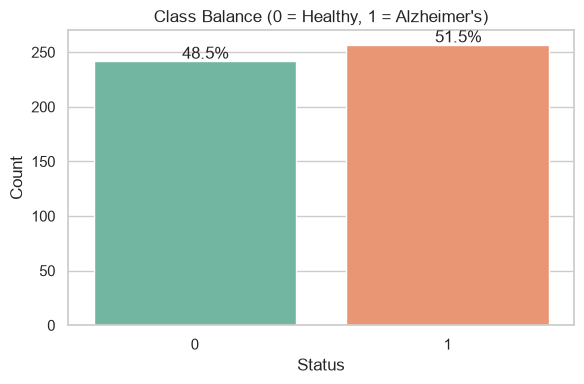

In [2]:
# 1. Target Class Balance
# This shows us exactly how balanced (or imbalanced) our positive/negative cases are.
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='status', hue='status', palette='Set2', legend=False)
plt.title("Class Balance (0 = Healthy, 1 = Alzheimer's)")
plt.xlabel("Status")
plt.ylabel("Count")

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_y() + p.get_height() + 2
    ax.annotate(percentage, (x, y))

plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/class_balance.png', dpi=300, bbox_inches='tight')
plt.show()


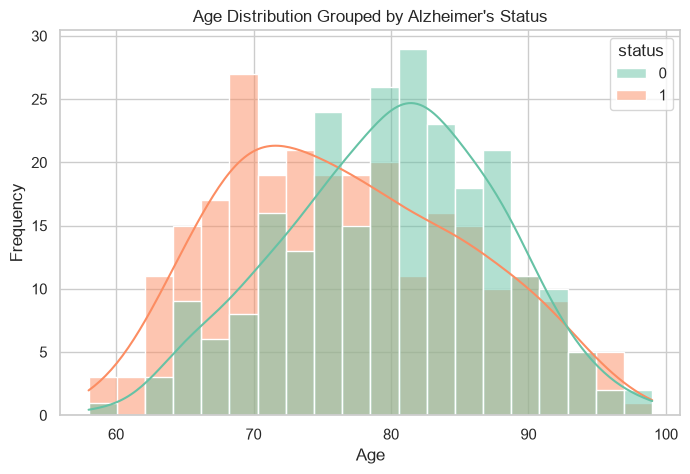

In [3]:
# 2. Age Distribution by Status
# Alzheimer's risk correlates strongly with age. We want to see if our dataset reflects this.
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='status', bins=20, kde=True, palette='Set2')
plt.title("Age Distribution Grouped by Alzheimer's Status")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.savefig('../results/figures/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


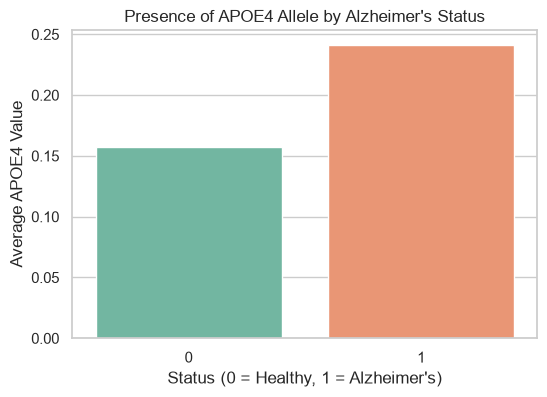

In [4]:
# 3. APOE Risk Factor Correlation
# The APOE4 allele is the most well-established genetic risk factor for Alzheimer's.
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='status', y='apoe4', hue='status', palette='Set2', errorbar=None, legend=False)
plt.title("Presence of APOE4 Allele by Alzheimer's Status")
plt.xlabel("Status (0 = Healthy, 1 = Alzheimer's)")
plt.ylabel("Average APOE4 Value")
plt.savefig('../results/figures/apoe4_correlation.png', dpi=300, bbox_inches='tight')
plt.show()
